# 순환 신경망 기반 감성 분석 (네이버 영화 리뷰)
1. 데이터 준비
2. 모델 구축 및 컴파일
3. 모델 학습
4. 모델 평가
5. 예측
6. 배포 (저장, 재사용)

## 1. 데이터 준비
    1-1. 데이터 로딩
    1-2. 데이터 전처리
    1-3. 데이터 분리 
    1-4. 학습용 데이터 준비
    1-5. 테스트용 데이터준비 

### 1-1. 데이터 로딩

In [1]:
# naver_movie_review.csv
datafile = './output/reviews_음식점_학습용.csv'
import pandas as pd
review_df = pd.read_csv(datafile)
review_df.head()

,place_name,rating,text,calculated_date,year,year_month,label
0,삿포로 카스소바와 텐푸라 풍토. 하카타 나카스 점,5,덴푸라바 소수로 여행오셔서 다양한 튀김 맛보면서 반주 원하신다면 너무나 추천합니다 ...,2026-02-23,2026,2026-02,1
1,삿포로 카스소바와 텐푸라 풍토. 하카타 나카스 점,5,지인한테 추천받고간건데 저도 완전추천 직원들부터 사장님 친절하고 재밌어요 한국어는 ...,2025-11-25,2025,2025-11,1
2,삿포로 카스소바와 텐푸라 풍토. 하카타 나카스 점,5,닭가슴살이 이렇게 육즙많고 부드러운지 몰랐어요 비싸긴 했지만 정말정말정말 맛있는 튀...,2026-02-23,2026,2026-02,1
3,삿포로 카스소바와 텐푸라 풍토. 하카타 나카스 점,5,전 예약을 해야한다해서 예약하고 갔는데 평일이라서 그런지 한가했어요 처음먹어본 따뜻...,2025-12-25,2025,2025-12,1
4,삿포로 카스소바와 텐푸라 풍토. 하카타 나카스 점,5,예약없이 6 30에 들어갔습니다 곱창 매운 소바 꼭 드셔보시길 오랫만에 매운거 먹으...,2025-12-25,2025,2025-12,1


In [2]:
!pip install "protobuf==3.19.3" --force-reinstall

  Using cached protobuf-3.19.3-cp39-cp39-win_amd64.whl.metadata (807 bytes)
Using cached protobuf-3.19.3-cp39-cp39-win_amd64.whl (895 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.19.3
    Uninstalling protobuf-3.19.3:
      Successfully uninstalled protobuf-3.19.3


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.50.0 requires protobuf<7,>=3.20, but you have protobuf 3.19.3 which is incompatible.


### 1-2. 데이터 전처리
- 결측치 제거
- 정제 (한글만 남기고 모두 삭제)
- 중복치 제거
- 형태소 분석기로 토큰화

#### 1-2-1. 결측치 제거

In [2]:
# 결측치 확인 (결측치 수)
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130404 entries, 0 to 130403
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   place_name       130404 non-null  object
 1   rating           130404 non-null  int64 
 2   text             130404 non-null  object
 3   calculated_date  130404 non-null  object
 4   year             130404 non-null  int64 
 5   year_month       130404 non-null  object
 6   label            130404 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 7.0+ MB


In [3]:
# 결측치가 있는 레코드(행) 확인
review_df[review_df.text.isnull()]

,place_name,rating,text,calculated_date,year,year_month,label


In [4]:
# 결측치 제거
review_df.dropna(inplace=True)

In [5]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130404 entries, 0 to 130403
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   place_name       130404 non-null  object
 1   rating           130404 non-null  int64 
 2   text             130404 non-null  object
 3   calculated_date  130404 non-null  object
 4   year             130404 non-null  int64 
 5   year_month       130404 non-null  object
 6   label            130404 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 7.0+ MB


#### 1-2-2. 정제
* 한글과 공백을 제외한 문자는 공백으로 치환하여 제거
* 한글이 없었던 문장은 공백만 남아있게 되므로, 결측치 삭제 처리 진행 필요

In [6]:
import re
# 한글과 공백 제외하고 모두 공백으로 치환
review_df['clean_doc'] = review_df.text.apply(lambda x: re.sub('[^ ㄱ-ㅣ가-힣]+', ' ', x))

# 문장의 시작 부분에 있는 공백을 ""으로 치환
review_df.clean_doc = review_df.clean_doc.apply(lambda x: re.sub('^ +', '', x))

# 빈 문자열("")은 결측치로 수정
review_df.clean_doc = review_df.clean_doc.replace('', None)

review_df.head()

,place_name,rating,text,calculated_date,year,year_month,label,clean_doc
0,삿포로 카스소바와 텐푸라 풍토. 하카타 나카스 점,5,덴푸라바 소수로 여행오셔서 다양한 튀김 맛보면서 반주 원하신다면 너무나 추천합니다 ...,2026-02-23,2026,2026-02,1,덴푸라바 소수로 여행오셔서 다양한 튀김 맛보면서 반주 원하신다면 너무나 추천합니다 ...
1,삿포로 카스소바와 텐푸라 풍토. 하카타 나카스 점,5,지인한테 추천받고간건데 저도 완전추천 직원들부터 사장님 친절하고 재밌어요 한국어는 ...,2025-11-25,2025,2025-11,1,지인한테 추천받고간건데 저도 완전추천 직원들부터 사장님 친절하고 재밌어요 한국어는 ...
2,삿포로 카스소바와 텐푸라 풍토. 하카타 나카스 점,5,닭가슴살이 이렇게 육즙많고 부드러운지 몰랐어요 비싸긴 했지만 정말정말정말 맛있는 튀...,2026-02-23,2026,2026-02,1,닭가슴살이 이렇게 육즙많고 부드러운지 몰랐어요 비싸긴 했지만 정말정말정말 맛있는 튀...
3,삿포로 카스소바와 텐푸라 풍토. 하카타 나카스 점,5,전 예약을 해야한다해서 예약하고 갔는데 평일이라서 그런지 한가했어요 처음먹어본 따뜻...,2025-12-25,2025,2025-12,1,전 예약을 해야한다해서 예약하고 갔는데 평일이라서 그런지 한가했어요 처음먹어본 따뜻...
4,삿포로 카스소바와 텐푸라 풍토. 하카타 나카스 점,5,예약없이 6 30에 들어갔습니다 곱창 매운 소바 꼭 드셔보시길 오랫만에 매운거 먹으...,2025-12-25,2025,2025-12,1,예약없이 에 들어갔습니다 곱창 매운 소바 꼭 드셔보시길 오랫만에 매운거 먹으니...


In [7]:
# 결측치 확인
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130404 entries, 0 to 130403
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   place_name       130404 non-null  object
 1   rating           130404 non-null  int64 
 2   text             130404 non-null  object
 3   calculated_date  130404 non-null  object
 4   year             130404 non-null  int64 
 5   year_month       130404 non-null  object
 6   label            130404 non-null  int64 
 7   clean_doc        130396 non-null  object
dtypes: int64(3), object(5)
memory usage: 8.0+ MB


In [8]:
review_df[review_df.clean_doc.isnull()]

,place_name,rating,text,calculated_date,year,year_month,label,clean_doc
4374,부타 매니아동 이나다야 선,5,2024 4 4 2025 12 26,2026-02-23,2026,2026-02,1,None
12775,하카타 야키니쿠 코우시,5,2026 03 08,2026-03-25,2026,2026-03,1,None
15330,야키니쿠 보우야 후쿠오카 원빌딩점,4,2025 05 09,2025-06-23,2025,2025-06,1,None
26109,우나리 라멘 나카스점,4,2026 4 3 0 12,2026-04-24,2026,2026-04,1,None
30284,타이호라멘 텐진,5,2023 12 16 13 50,2024-06-23,2024,2024-06,1,None
36665,멘야 타이손,5,2019 2018,2025-06-23,2025,2025-06,1,None
68036,앤드로컬스 오호리공원,5,202402,2026-04-24,2026,2026-04,1,None
108041,모토무라 규카츠,5,1 300 500,2023-06-24,2023,2023-06,1,None


In [9]:
# 결측치 제거
review_df.dropna(inplace=True)

In [10]:
review_df.clean_doc.isnull().sum()

0

#### 1-2-3. 중복치 제거

In [11]:
# 중복치 확인
review_df.clean_doc.duplicated().sum()

1745

In [12]:
review_df[review_df.clean_doc.duplicated()]

,place_name,rating,text,calculated_date,year,year_month,label,clean_doc
505,삿포로 카스소바와 텐푸라 풍토. 하카타 나카스 점,5,너무 좋아요,2025-11-25,2025,2025-11,1,너무 좋아요
6875,긴샤리 야키니쿠호르몬,5,맛있었습니다,2025-12-25,2025,2025-12,1,맛있었습니다
6877,긴샤리 야키니쿠호르몬,5,너무 맛있어요,2025-10-26,2025,2025-10,1,너무 맛있어요
7067,긴샤리 야키니쿠호르몬,5,맛있었습니다,2026-02-23,2026,2026-02,1,맛있었습니다
7302,우오츄,5,훌륭한 식사였습니다,2025-06-23,2025,2025-06,1,훌륭한 식사였습니다
...,...,...,...,...,...,...,...,...
130048,하카타호타루,5,접객도 요리도 최고입니다,2018-06-25,2018,2018-06,1,접객도 요리도 최고입니다
130062,하카타호타루,5,세련되고 맛있는,2020-06-24,2020,2020-06,1,세련되고 맛있는
130070,하카타호타루,4,요리 맛있었습니다,2026-03-25,2026,2026-03,1,요리 맛있었습니다
130389,우메보시,5,정말 맛있어요,2025-07-28,2025,2025-07,1,정말 맛있어요


In [13]:
# 중복치 제거
review_df.drop_duplicates(subset=['clean_doc'], inplace=True)

In [14]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128651 entries, 0 to 130403
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   place_name       128651 non-null  object
 1   rating           128651 non-null  int64 
 2   text             128651 non-null  object
 3   calculated_date  128651 non-null  object
 4   year             128651 non-null  int64 
 5   year_month       128651 non-null  object
 6   label            128651 non-null  int64 
 7   clean_doc        128651 non-null  object
dtypes: int64(3), object(5)
memory usage: 8.8+ MB


#### 1-2-4. 토큰화

In [15]:
from konlpy.tag import Okt
from tqdm import tqdm

t = Okt()
tqdm.pandas()


# 💡 명사, 형용사에 [동사, 부사]까지 추가하여 감정 신호를 복원하는 함수
def extract_useful_pos(text):
    # 단어와 품사를 같이 추출하며 원형(stem)으로 복원
    pos_tagged = t.pos(str(text), stem=True)

    # 🚀 [수정] Verb(동사)와 Adverb(부사)를 필터에 추가합니다!
    clean_words = [
        word
        for word, tag in pos_tagged
        if tag in ["Noun", "Adjective", "Verb", "Adverb"]
    ]
    return clean_words


# ⚡ 전량 토큰화 다시 진행! (새로운 함수 적용)
review_df["tokens"] = review_df["clean_doc"].progress_apply(extract_useful_pos)

# 잘 되었는지 5개 확인
print(review_df[["text", "tokens"]].head())

100%|██████████| 128651/128651 [05:31<00:00, 388.60it/s] 

                                                text  \
0  덴푸라바 소수로 여행오셔서 다양한 튀김 맛보면서 반주 원하신다면 너무나 추천합니다 ...   
1  지인한테 추천받고간건데 저도 완전추천 직원들부터 사장님 친절하고 재밌어요 한국어는 ...   
2  닭가슴살이 이렇게 육즙많고 부드러운지 몰랐어요 비싸긴 했지만 정말정말정말 맛있는 튀...   
3  전 예약을 해야한다해서 예약하고 갔는데 평일이라서 그런지 한가했어요 처음먹어본 따뜻...   
4  예약없이 6 30에 들어갔습니다 곱창 매운 소바 꼭 드셔보시길 오랫만에 매운거 먹으...   

                                              tokens  
0  [덴푸라, 바, 소수, 여행, 오다, 다양하다, 튀김, 맛보다, 반주, 원하다, 너...  
1  [지인, 추천, 받다, 가다, 저, 완전, 추천, 직원, 사장, 친절하다, 재밌다,...  
2  [닭, 가슴, 살이, 이렇게, 육즙, 많다, 부드럽다, 모르다, 비싸다, 하다, 맛...  
3  [전, 예약, 하다, 한다해, 예약, 가다, 평일, 그렇다, 한가하다, 처음, 먹다...  
4  [예약, 없이, 들어가다, 곱창, 맵다, 소바, 꼭, 들다, 보다, 만, 맵다, 먹...  


In [16]:
review_df.head()

,place_name,rating,text,calculated_date,year,year_month,label,clean_doc,tokens
0,삿포로 카스소바와 텐푸라 풍토. 하카타 나카스 점,5,덴푸라바 소수로 여행오셔서 다양한 튀김 맛보면서 반주 원하신다면 너무나 추천합니다 ...,2026-02-23,2026,2026-02,1,덴푸라바 소수로 여행오셔서 다양한 튀김 맛보면서 반주 원하신다면 너무나 추천합니다 ...,"[덴푸라, 바, 소수, 여행, 오다, 다양하다, 튀김, 맛보다, 반주, 원하다, 너..."
1,삿포로 카스소바와 텐푸라 풍토. 하카타 나카스 점,5,지인한테 추천받고간건데 저도 완전추천 직원들부터 사장님 친절하고 재밌어요 한국어는 ...,2025-11-25,2025,2025-11,1,지인한테 추천받고간건데 저도 완전추천 직원들부터 사장님 친절하고 재밌어요 한국어는 ...,"[지인, 추천, 받다, 가다, 저, 완전, 추천, 직원, 사장, 친절하다, 재밌다,..."
2,삿포로 카스소바와 텐푸라 풍토. 하카타 나카스 점,5,닭가슴살이 이렇게 육즙많고 부드러운지 몰랐어요 비싸긴 했지만 정말정말정말 맛있는 튀...,2026-02-23,2026,2026-02,1,닭가슴살이 이렇게 육즙많고 부드러운지 몰랐어요 비싸긴 했지만 정말정말정말 맛있는 튀...,"[닭, 가슴, 살이, 이렇게, 육즙, 많다, 부드럽다, 모르다, 비싸다, 하다, 맛..."
3,삿포로 카스소바와 텐푸라 풍토. 하카타 나카스 점,5,전 예약을 해야한다해서 예약하고 갔는데 평일이라서 그런지 한가했어요 처음먹어본 따뜻...,2025-12-25,2025,2025-12,1,전 예약을 해야한다해서 예약하고 갔는데 평일이라서 그런지 한가했어요 처음먹어본 따뜻...,"[전, 예약, 하다, 한다해, 예약, 가다, 평일, 그렇다, 한가하다, 처음, 먹다..."
4,삿포로 카스소바와 텐푸라 풍토. 하카타 나카스 점,5,예약없이 6 30에 들어갔습니다 곱창 매운 소바 꼭 드셔보시길 오랫만에 매운거 먹으...,2025-12-25,2025,2025-12,1,예약없이 에 들어갔습니다 곱창 매운 소바 꼭 드셔보시길 오랫만에 매운거 먹으니...,"[예약, 없이, 들어가다, 곱창, 맵다, 소바, 꼭, 들다, 보다, 만, 맵다, 먹..."


### 1-3. 데이터 분리
* 정답 데이터의 분포 확인 -> 학습용 데이터와 테스트 데이터로 분리 시 비율 유지 (stratify=y)

In [17]:
# label 컬럼의 값별 데이터 수 확인
review_df.label.value_counts()
# review_df.groupby('label').size()

label
1    118575
0     10076
Name: count, dtype: int64

<Axes: xlabel='label'>

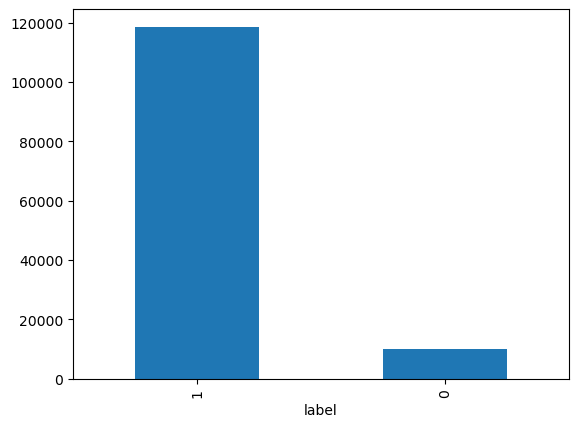

In [18]:
# 막대그래프로 그려보기
review_df.label.value_counts().plot(kind='bar')
# review_df.groupby('label').size().plot(kind='bar')

In [19]:
# 입력 데이터와 정답데이터 추출  (list)
review_list = list(review_df.tokens)
label_list = list(review_df.label)
len(review_list), len(label_list)

(128651, 128651)

In [20]:
# 학습 데이터와 테스트 데이터 분리
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(review_list, label_list, test_size=0.1, stratify=label_list, random_state=42)
len(train_X), len(test_X), len(train_y), len(test_y)

(115785, 12866, 115785, 12866)

### 1-4. 학습 데이터 준비
    1-4-1. Integer Encoding을 위한 tokenizer 생성
    1-4-2. 입력 데이터 Integer Encoding
    1-4-3. 입력 데이터 Padding
    1-4-4. 정답 데이터 원핫인코딩

#### 1-4-1. Integer Encoding을 위한 tokenizer 생성
* num_words = 사용할 단어 수(vocab_size) + 1 (0은 OOV에 할당)

In [21]:
# 단어 수 제한없이 Tokenizer 생성하여 단어 수 확인
from tensorflow.keras.preprocessing.text import Tokenizer
test_tokenizer = Tokenizer()
test_tokenizer.fit_on_texts(train_X)
len(test_tokenizer.word_index)

31016

In [22]:
# 등장 빈도수를 threshold로 설정하여 버릴 단어가 차지하는 비율 확인
from mylib.my_utils import under_threshold_per
threshold = 3
under_threshold_per(threshold, test_tokenizer.word_counts.items())

전체 단어 : 31,016개 3,074,339번
희귀 단어 (등장빈도 3번 미만) : 15,862개 19,466번
희귀 단어 비율 : 단어수 51.14%, 빈도수 0.63%
희귀 단어를 뺀 단어 수 : 15,154개 99.37%


In [23]:
# 단어 수를 제한하여 tokenizer 생성
num_vocab = 15000
num_words = num_vocab + 1
tokenizer = Tokenizer(num_words=num_words, oov_token='<OOV>')
tokenizer.fit_on_texts(train_X)
len(tokenizer.word_counts), tokenizer.num_words

(31016, 15001)

#### 1-4-2. 입력 데이터 Integer Encoding
* 제한된 단어에만 index를 부여하므로, 희귀 단어로만 구성된 review는 단어가 0이 되므로 결측치에 해당 -> 결측치 제거

In [24]:
# 입력 데이터 Integer Encoding
encoded_train_X = tokenizer.texts_to_sequences(train_X)
print(len(encoded_train_X))
print(encoded_train_X[:5])

115785
[[186, 3, 818, 63, 559, 2038, 3, 261, 132, 126, 71, 1257, 1069, 1, 1069, 48, 71, 32, 1816, 253, 4], [29, 4, 15, 58, 5306, 5740, 431, 7, 133, 136, 41, 356, 691, 54, 658, 116, 334, 49], [1007, 645, 1534, 25, 77, 5, 212, 147, 4, 638, 349, 101, 8, 313, 109, 10, 3, 9, 42, 6, 142, 51, 2783, 5, 2409, 1453, 3, 8, 62, 412, 50, 173, 600, 505, 246, 43, 1879, 206, 25, 17, 65, 551, 14, 24, 359, 32, 15, 6], [4949, 222, 22, 2], [195, 860, 2204, 15, 33, 2, 169, 4, 660, 631, 583, 3, 78, 21, 1833, 372, 1282, 10, 3, 33, 536, 21, 958, 605, 221, 1116, 10, 493, 6980, 552, 44, 58, 258, 18, 2177, 1055, 3]]


In [25]:
# 길이가 0인 리뷰의 index 추출
null_index = [index for index, review in enumerate(encoded_train_X) if len(review) < 1]
len(null_index)

0

In [26]:
# 길이가 0인 리뷰가 있는 경우, 길이가 1 이상인 리뷰로 학습데이터 재구성
new_train_X = [review for index, review in enumerate(encoded_train_X) if index not in null_index]
new_train_y = [label for index, label in enumerate(train_y) if index not in null_index]
len(new_train_X), len(new_train_y)

(115785, 115785)

In [27]:
new_train_X = []
new_train_y = []
for i in range(len(encoded_train_X)):
    if len(encoded_train_X[i]) > 0:
        new_train_X.append(encoded_train_X[i])
        new_train_y.append(train_y[i])

len(new_train_X), len(new_train_y)

(115785, 115785)

#### 1-4-3. 입력 데이터 padding
* 입력 데이터의 길이(max_len)를 정하여 padding

array([[<Axes: title={'center': '0'}>]], dtype=object)

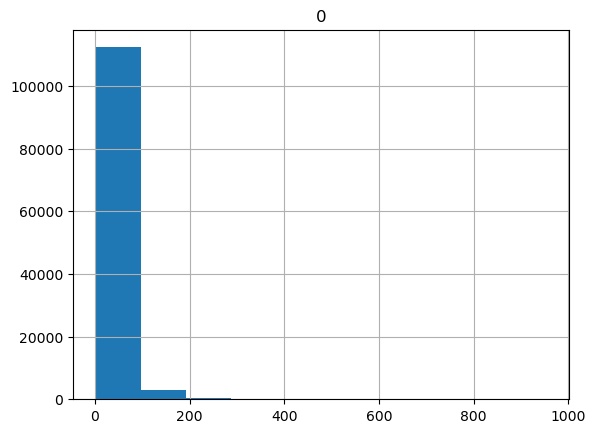

In [28]:
# 리뷰 길이 분포 확인 (히스토그램 그려보기)
len_df = pd.DataFrame([len(review) for review in new_train_X])
len_df.hist()

In [29]:
# 최대, 최소, 평균 등 정보 확인
len_df.describe()

,0
count,115785.000000
mean,26.552135
std,29.658414
min,1.000000
25%,9.000000
50%,18.000000
75%,33.000000
max,954.000000


In [30]:
import importlib
import mylib.my_utils
importlib.reload(mylib.my_utils)

<module 'mylib.my_utils' from 'd:\\Lecture\\TextMining26\\Apps\\GoogleReviewCrawler\\mylib\\my_utils.py'>

In [38]:
# 길이가 max_len 이하인 데이터의 비중 확인
from mylib.my_utils import below_threshold_len_from_list
max_len = 90
below_threshold_len_from_list(max_len, new_train_X)

길이가 90 이하인 텍스트의 비율 : 96.45%


In [39]:
# max_len 길이로 입력 데이터 padding
from tensorflow.keras.preprocessing.sequence import pad_sequences
train_X = pad_sequences(new_train_X, maxlen=max_len)
len(train_X), train_X[:2]

(115785,
 array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,  186,    3,  818,   63,  559, 2038,    3,  261,
          132,  126,   71, 1257, 1069,    1, 1069,   48,   71,   32, 1816,
          253,    4],
        [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0, 

#### 1-4-4. 정답 데이터 one-hot encoding

In [40]:
from tensorflow.keras.utils import to_categorical
train_y = to_categorical(new_train_y)
len(train_y), train_y[:2]

(115785,
 array([[0., 1.],
        [0., 1.]], dtype=float32))

### 1-5. 테스트 데이터 준비
    1-5-1. 입력 데이터 Integer Encoding (결측치제거) 
    1-5-2. 입력 데이터 padding
    1-5-3. 정답 데이터 one-hot encoding

In [41]:
# 입력 데이터 Integer Encoding
encoded_test_X = tokenizer.texts_to_sequences(test_X)
print(len(encoded_test_X), encoded_test_X[:2])

12866 [[194, 55, 4, 113, 38, 391, 1624, 6, 36, 340, 245, 1088, 2626, 159, 889, 599, 2402, 54, 2], [3216, 2209, 393, 904, 67, 3281, 5, 10, 3, 169, 4, 202, 41, 762, 15, 4189, 12, 33, 2]]


In [42]:
# 길이가 0인 리뷰의 index 추출 -> 있으면 길이가 1 이상인 리뷰만으로 테스트 데이터 재구성 
null_index = [index for index, review in enumerate(encoded_test_X) if len(review) < 1]
len(null_index)

0

In [43]:
new_test_X = [review for index, review in enumerate(encoded_test_X) if index not in null_index]
new_test_y = [review for index, review in enumerate(test_y) if index not in null_index]
len(new_test_X), len(new_test_y)

(12866, 12866)

In [44]:
# 입력 데이터 padding
test_X = pad_sequences(new_test_X, maxlen=max_len)
len(test_X), test_X[:2]

(12866,
 array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,  194,   55,    4,  113,   38,  391,
         1624,    6,   36,  340,  245, 1088, 2626,  159,  889,  599, 2402,
           54,    2],
        [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,  

In [45]:
# 정답 데이터 one-hot encoding
test_y = to_categorical(new_test_y)
len(test_y), test_y[:2]

(12866,
 array([[0., 1.],
        [0., 1.]], dtype=float32))

## 2. 모델 구축 및 컴파일

In [ ]:
# # 모델 설계
# from tensorflow.keras.layers import Embedding, LSTM, Dense
# # Embedding layer의 파라미터
# num_features = num_words
# embedding_dim = 32
# input_length = max_len

# rnn_nodes = 32

# dense_nodes = 16

# output_nodes = 2

# rnn_model =[
#     Embedding(num_features, embedding_dim),
#     LSTM(rnn_nodes),
#     Dense(dense_nodes, activation='tanh'),
#     Dense(output_nodes, activation='softmax')
# ]

In [ ]:
# # 모델 생성
# from tensorflow.keras.models import Sequential
# model = Sequential(rnn_model)
# model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 32)          480032    
                                                                 
 lstm (LSTM)                 (None, 32)                8320      
                                                                 
 dense (Dense)               (None, 16)                528       
                                                                 
 dense_1 (Dense)             (None, 2)                 34        
                                                                 
Total params: 488,914
Trainable params: 488,914
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# 모델 설계 및 생성 (CNN + 2층 GRU 하이브리드 고도화)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, Bidirectional, GRU, Dense, Dropout

num_features = num_words
embedding_dim = 64
input_length = max_len

gru_nodes = 64
dense_nodes = 32
output_nodes = 2

upgrade_model_layers = [
    # 1. 임베딩 레이어 (기존 동일)
    Embedding(num_features, embedding_dim, input_length=input_length),
    
    # Conv1D 레이어
    # 번역체 문장에서 핵심이 되는 단어 묶음(kernel_size=3) 패턴 64개를 포착합니다.
    Conv1D(filters=64, kernel_size=4, padding='same', activation='relu'),
    Dropout(0.3),
    
    # 2. 1층 GRU (CNN이 추출한 특징을 받아 시계열 문맥 파악, return_sequences=True 유지)
    Bidirectional(GRU(gru_nodes, return_sequences=True)),
    Dropout(0.3),
    
    # 3. 2층 GRU (더 깊은 문맥 파악)
    Bidirectional(GRU(32, return_sequences=False)),
    Dropout(0.3),
    
    # 4. 출력층 및 밀집층
    Dense(dense_nodes, activation='relu'),
    Dropout(0.3),
    Dense(output_nodes, activation='softmax')
]

model = Sequential(upgrade_model_layers)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 90, 64)            960064    
                                                                 
 conv1d (Conv1D)             (None, 90, 64)            16448     
                                                                 
 dropout (Dropout)           (None, 90, 64)            0         
                                                                 
 bidirectional (Bidirectiona  (None, 90, 128)          49920     
 l)                                                              
                                                                 
 dropout_1 (Dropout)         (None, 90, 128)           0         
                                                                 
 bidirectional_1 (Bidirectio  (None, 64)               31104     
 nal)                                                   

In [ ]:
# # 학습 설계 : 생성한 모델에 학습 관련 하이퍼파라미터를 설정
# from tensorflow.keras.optimizers import RMSprop
# model.compile(loss='categorical_crossentropy', metrics='accuracy', optimizer=RMSprop(learning_rate=0.001))

In [47]:
# 학습 설계
from tensorflow.keras.optimizers import RMSprop

model.compile(loss='categorical_crossentropy', 
              metrics=['accuracy'], 
              optimizer=RMSprop(learning_rate=0.0003))

In [ ]:
# import tensorflow as tf
# from tensorflow.keras import backend as K

# # Precision과 Recall의 조화평균(F1)을 직접 손실함수로 주입하여 이를 극대화하도록 유도
# def f1_loss(y_true, y_pred):
#     tp = K.sum(K.cast(y_true * y_pred, 'float'), axis=0)
#     tn = K.sum(K.cast((1 - y_true) * (1 - y_pred), 'float'), axis=0)
#     fp = K.sum(K.cast((1 - y_true) * y_pred, 'float'), axis=0)
#     fn = K.sum(K.cast(y_true * (1 - y_pred), 'float'), axis=0)

#     p = tp / (tp + fp + K.epsilon())
#     r = tp / (tp + fn + K.epsilon())

#     f1 = 2 * p * r / (p + r + K.epsilon())
#     f1 = tf.where(tf.math.is_nan(f1), tf.zeros_like(f1), f1)
#     return 1 - K.mean(f1)

# # 컴파일할 때 loss에 주입
# model.compile(loss=f1_loss, metrics=['accuracy'], optimizer=RMSprop(learning_rate=0.0003))

In [48]:
# EarlyStopping, ModelCheckpoint callback 함수 설정
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
es = EarlyStopping(monitor='val_loss', mode='min', patience=3, verbose=1) # monitor 뭐를 모니터하다가 정지할건지?, mode monitor가 가는방향, patience 이만큼 기다렸다가 멈춰!, verbose 중간에 학습과정을 나한테 보여줘!
checkpoint_filepath = './model/best_model.h5'
mc = ModelCheckpoint(checkpoint_filepath, monitor='val_loss', mode='min', save_best_only=True) # save_best_only 모니터하고 있는게 mode(모니터가 좋은쪽) 방향으로 가면 저장!
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)

## 3. 모델 학습

In [ ]:
# # 모델 학습
# from sklearn.utils import class_weight
# import numpy as np

# class_weight_dict = {0: 4.2, 1: 1.0} 
# print("실험을 위해 수동 설정한 클래스별 가중치:", class_weight_dict)


# # 4. [기존 코드 수정] 맨 뒤에 class_weight=class_weight_dict 옵션을 추가해서 학습 시작!
# model.fit(train_X, train_y, 
#           epochs=20, 
#           batch_size=64, 
#           validation_split=0.1, 
#           callbacks=[es, mc, lr_scheduler],
#           class_weight=class_weight_dict) # <--- 여기에 가중치를 배달해 줍니다!


실험을 위해 수동 설정한 클래스별 가중치: {0: 4.2, 1: 1.0}
Epoch 1/20
1628/1628 [==============================] - 83s 50ms/step - loss: 0.3384 - accuracy: 0.9257 - val_loss: 0.1677 - val_accuracy: 0.9362 - lr: 0.0010
Epoch 2/20
1628/1628 [==============================] - 84s 52ms/step - loss: 0.3257 - accuracy: 0.9320 - val_loss: 0.1819 - val_accuracy: 0.9265 - lr: 0.0010
Epoch 3/20
1627/1628 [============================>.] - ETA: 0s - loss: 0.3160 - accuracy: 0.9348
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
1628/1628 [==============================] - 83s 51ms/step - loss: 0.3159 - accuracy: 0.9349 - val_loss: 0.1976 - val_accuracy: 0.9254 - lr: 0.0010
Epoch 4/20
1628/1628 [==============================] - 82s 50ms/step - loss: 0.2887 - accuracy: 0.9423 - val_loss: 0.1711 - val_accuracy: 0.9335 - lr: 2.0000e-04
Epoch 4: early stopping


In [ ]:
# 3. 모델 학습 (5-Fold Cross Validation 앙상블 및 Precision 보정 버전)
from sklearn.model_selection import StratifiedKFold
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint

class_weight_dict = {0: 2.8, 1: 1.0} 
print("Precision 보정을 위해 새롭게 수동 설정한 클래스별 가중치:", class_weight_dict)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold = 1

# 테스트 데이터에 대한 5개 모델의 예측 확률을 평균 내기 위해 누적할 배열
# 컴파일 및 출력 형태에 맞춰 test_X 크기만큼 0으로 초기화합니다.
oof_preds = np.zeros((len(test_X), 2))

# 원-핫 인코딩 상태인 정답을 StratifiedKFold가 인식할 수 있게 정수(0 또는 1) 형태로 잠시 변환
y_ints = np.argmax(train_y, axis=1)

#  5번의 루프를 돌며 5개의 독립된 최적 모델 생성 및 학습 시작!
for train_idx, val_idx in skf.split(train_X, y_ints):
    print(f"\n================ FOLD {fold} / 5 START ================")
    
    # 이번 Fold에서 사용할 학습 데이터와 자체 검증 데이터 분할
    X_tr, y_tr = train_X[train_idx], train_y[train_idx]
    X_val, y_val = train_X[val_idx], train_y[val_idx]
    
    # [매우 중요] 매 루프마다 모델의 메모리를 완전히 리셋하여 새 모델을 빌드합니다.
    # 기존 코드 상단에 선언해 두신 'upgrade_model_layers' 구조를 그대로 가져옵니다.
    model = Sequential(upgrade_model_layers)
    
    # 컴파일 설정 (기존 사용하시던 손실함수와 옵티마이저 세팅 유지)
    model.compile(loss='categorical_crossentropy', 
                  metrics=['accuracy'], 
                  optimizer=RMSprop(learning_rate=0.0003))
    
    # 폴드별로 가장 검증 손실(val_loss)이 낮은 최고의 순간을 개별 파일로 저장합니다.
    checkpoint_filepath = f'./model/best_model_fold{fold}.h5'
    mc = ModelCheckpoint(checkpoint_filepath, monitor='val_loss', mode='min', save_best_only=True)
    
    # 학습 진행 (validation_split 대신 쪼개진 100% 순수한 내부 검증 데이터를 주입합니다)
    model.fit(X_tr, y_tr, 
              validation_data=(X_val, y_val),
              epochs=20, 
              batch_size=32, 
              callbacks=[es, mc, lr_scheduler], # 조기종료, 스케줄러, 해당 폴드용 저장 콜백
              class_weight=class_weight_dict,
              verbose=1)
    
    print(f"FOLD {fold} 학습 완료! 최고 가중치 파일을 로드하여 테스트 데이터 예측 중...")
    # 방금 저장된 이번 폴드 최강의 가중치 파일을 다시 로드
    model.load_weights(checkpoint_filepath)
    
    # 테스트 데이터를 예측하고, 그 확률 결과의 5분의 1씩을 최종 배열에 누적 (평균 처리)
    oof_preds += model.predict(test_X) / 5.0
    
    fold += 1

print("\n================ 모든 5-Fold 앙상블 학습이 종료되었습니다 ================")

Precision 보정을 위해 새롭게 수동 설정한 클래스별 가중치: {0: 2.8, 1: 1.0}

================ 🔥 FOLD 1 / 5 START ================
Epoch 1/20
2895/2895 [==============================] - 149s 51ms/step - loss: 0.3485 - accuracy: 0.9260 - val_loss: 0.3755 - val_accuracy: 0.8289 - lr: 3.0000e-04
Epoch 2/20
2895/2895 [==============================] - 132s 46ms/step - loss: 0.2722 - accuracy: 0.9393 - val_loss: 0.1467 - val_accuracy: 0.9499 - lr: 3.0000e-04
Epoch 3/20
2895/2895 [==============================] - 135s 47ms/step - loss: 0.2534 - accuracy: 0.9450 - val_loss: 0.1330 - val_accuracy: 0.9510 - lr: 3.0000e-04
Epoch 4/20
2895/2895 [==============================] - 138s 48ms/step - loss: 0.2411 - accuracy: 0.9482 - val_loss: 0.1298 - val_accuracy: 0.9526 - lr: 3.0000e-04
Epoch 5/20
2895/2895 [==============================] - 139s 48ms/step - loss: 0.2357 - accuracy: 0.9485 - val_loss: 0.1349 - val_accuracy: 0.9495 - lr: 3.0000e-04
Epoch 6/20
2895/2895 [==============================] - ETA: 0s - loss:

In [53]:
import pickle

# 메모리에 있는 tokenizer 객체를 파일로 안전하게 저장합니다.
with open("./model/my_best_tokenizer.pickle", "wb") as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("✅ [1단계 성공] 토크나이저 파일(my_best_tokenizer.pickle) 저장 완료!")

✅ [1단계 성공] 토크나이저 파일(my_best_tokenizer.pickle) 저장 완료!


## 4. 모델 평가

In [118]:
# 저장된 모델 로딩하여, 테스트 데이터로 평가
model.load_weights(checkpoint_filepath)
test_loss, test_acc = model.evaluate(test_X, test_y)
print(f'정확도 : {test_acc * 100:.3f}%')

403/403 [==============================] - 9s 23ms/step - loss: 0.1485 - accuracy: 0.9459
정확도 : 94.590%


In [119]:
# predict로 테스트 데이터의 예측값 구기기
import numpy as np
results = model.predict(test_X)
print(results[:1])
labels = ['부정', '긍정']
user_outputs = [labels[np.argmax(result)] for result in results]
print(user_outputs[:10])

403/403 [==============================] - 9s 23ms/step
[[0.18597841 0.8140216 ]]
['긍정', '긍정', '긍정', '긍정', '부정', '긍정', '긍정', '긍정', '긍정', '긍정']


In [ ]:
# # sklearn의 classification_report()로 평가 결과 확인
# from sklearn.metrics import classification_report
# pred_labels = [0, 1]
# preds = [pred_labels[np.argmax(result)] for result in results]
# print(classification_report(new_test_y, preds))

              precision    recall  f1-score   support

           0       0.58      0.73      0.64      1008
           1       0.98      0.95      0.97     11857

    accuracy                           0.94     12865
   macro avg       0.78      0.84      0.81     12865
weighted avg       0.95      0.94      0.94     12865



In [52]:
# [최적의 임계값 자동 탐색 코드]
from sklearn.metrics import f1_score, classification_report
import numpy as np

best_macro_f1 = 0
best_threshold = 0.5
best_preds = None

# 임계값을 0.45부터 0.65까지 0.01 단위로 촘촘하게 전부 테스트해봅니다.
for th in np.arange(0.45, 0.66, 0.01):
    temp_preds = []
    for result in oof_preds:
        if result[0] >= th:
            temp_preds.append(0)
        else:
            temp_preds.append(1)
            
    # Macro F1 점수 계산
    current_macro_f1 = f1_score(new_test_y, temp_preds, average='macro')
    
    # 최고 점수 갱신 시 기록
    if current_macro_f1 > best_macro_f1:
        best_macro_f1 = current_macro_f1
        best_threshold = th
        best_preds = temp_preds

print(f"🏆 [탐색 결과] 가장 Macro F1이 높게 나오는 최적의 임계값: {best_threshold:.2f}")
print(f"📊 [최고 Macro F1 점수]: {best_macro_f1:.4f}\n")
print(classification_report(new_test_y, best_preds))

🏆 [탐색 결과] 가장 Macro F1이 높게 나오는 최적의 임계값: 0.53
📊 [최고 Macro F1 점수]: 0.8523

              precision    recall  f1-score   support

           0       0.75      0.71      0.73      1008
           1       0.98      0.98      0.98     11858

    accuracy                           0.96     12866
   macro avg       0.86      0.84      0.85     12866
weighted avg       0.96      0.96      0.96     12866

